# Support Vector Regression Model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Position_Salaries.csv')
print(dataset)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [5]:
x = dataset.iloc[:, 1:-1].values
print(x)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [6]:
y = dataset.iloc[:, -1].values
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


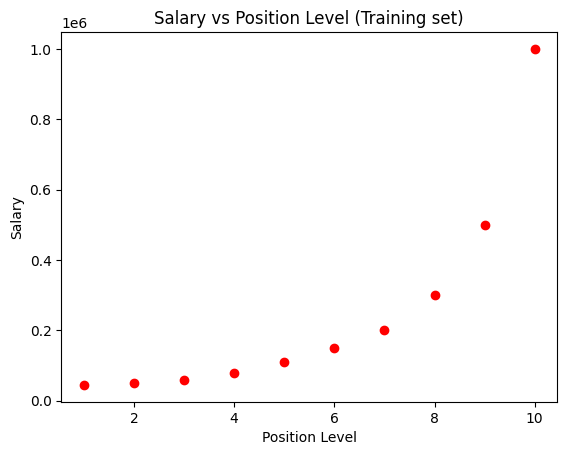

In [7]:
plt.scatter(x, y, color='red')
plt.title('Salary vs Position Level (Training set)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

In [8]:
print(y.shape)

(10,)


In [9]:
y = y.reshape(len(y), 1)
print(y.shape)
print(y)

(10, 1)
[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


**Feature Scaling**

In [12]:
from sklearn.preprocessing import StandardScaler
sc_position = StandardScaler()
x = sc_position.fit_transform(x)
print(x)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [13]:
from sklearn.preprocessing import StandardScaler
sc_salary = StandardScaler()
y = sc_salary.fit_transform(y)
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


**Training the SVR model on the whole dataset**

In [17]:
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(x, y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

**Predicting New Results**

In [18]:
sc_salary.inverse_transform(regressor.predict(sc_position.transform([[6.5]])).reshape(-1,1))

array([[0.01150915]])